In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix 

data = load_iris()
x = data.data 
y = data.target 
feature_name = data.feature_names 
class_names = data.target_names 
x_train, x_test, y_train, y_test = train_test_split(x , y , test_size=0.25 , stratify= y ) 

print("Training Samples: ", x_train.shape[0])
print("Test Samples: ", x_test.shape[0])


rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth= None, 
    random_state= 42 
)

rf.fit(x_train, y_train) 

#evaluate performance 

y_pred = rf.predict(x_test)

acc = accuracy_score(y_test , y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\nRandom forest accuracy : ", round(acc, 4))
print("\nconfusion matrix : \n", cm)


Training Samples:  112
Test Samples:  38

Random forest accuracy :  0.9474

confusion matrix : 
 [[12  0  0]
 [ 0 11  2]
 [ 0  0 13]]


In [18]:
best_acc = 0 
best_n = None 
for n in [20, 50, 100, 200]:
    model = RandomForestClassifier(
        n_estimators=n , 
        random_state=42 
    )

    model.fit(x_train, y_train) 
    pred = model.predict(x_test) 
    acc_n = accuracy_score(y_test , y_pred) 
    print(f"n_estimators={n}: accuracy= {acc_n:.4f}")
    if acc_n> best_acc:
        best_acc = acc_n 
        best_n = n 

print(f"\n Best n_estimators selected: ", best_n)
        

n_estimators=20: accuracy= 0.9474
n_estimators=50: accuracy= 0.9474
n_estimators=100: accuracy= 0.9474
n_estimators=200: accuracy= 0.9474

 Best n_estimators selected:  20


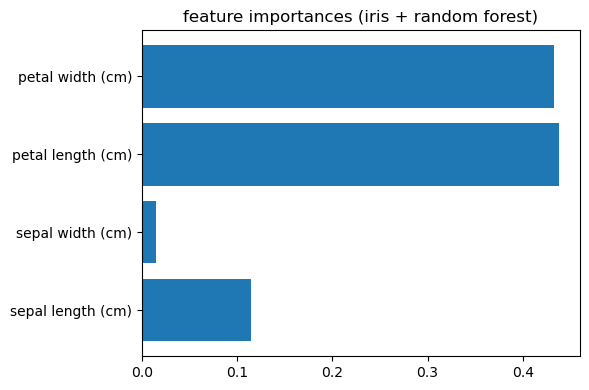

In [20]:
importances = rf.feature_importances_ 
idx = np.argsort(importances) 

plt.figure(figsize=(6, 4 ))
plt.barh(feature_name, importances)
plt.title("feature importances (iris + random forest)")

plt.tight_layout() 
plt.show()